# 02 — Time of Flight

## Purpose

Measure the raw ADC readout trace to estimate the signal arrival time (time of flight) at the digitizer. This timing check ensures the readout integration window is correctly positioned before any resonator or qubit frequency scans.

## Methodology

1. **Readout trace acquisition** — drive the readout resonator at its configured frequency and capture the raw ADC I/Q time series
2. **Envelope estimation** — compute the IQ envelope √(I² + Q²) and locate the first sample exceeding a configurable threshold fraction above the baseline
3. **Visual inspection** — overlay the raw ADC traces and the envelope with an arrival-time marker for manual verification

## Expected Outcomes

- A clear signal arrival visible in the ADC envelope plot
- The estimated arrival sample aligns with the hardware `time_of_flight` parameter (typically 200–400 samples)
- ADC baseline offsets are small (< 10 mV) — if not, check ADC offset calibration in notebook 00

## Prerequisites

- **Notebook 00** — hardware session established
- **Notebook 01** — mixer calibration complete (recommended, not strictly required)

## 1. Setup — Session Bootstrap

Reopen the shared session established by notebook 00. If the session is already live in the current kernel, it is reused directly.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "qubox").exists():
    REPO_ROOT = Path(r"E:\qubox")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from qubox.notebook import (
    ReadoutTrace,
    close_shared_session,
    get_notebook_session_bootstrap_path,
    get_shared_session,
    require_shared_session,
)

REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2026_03_24"
QOP_IP = "10.157.36.68"
CLUSTER_NAME = "Cluster_2"
SESSION_BOOTSTRAP_PATH = get_notebook_session_bootstrap_path(
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    registry_base=REGISTRY_BASE,
)

existing_session = get_shared_session()
if existing_session is not None:
    close_shared_session()
session = require_shared_session(
    registry_base=REGISTRY_BASE,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    qop_ip=QOP_IP,
    cluster_name=CLUSTER_NAME,
    force_reopen=True,
)
context_snapshot = getattr(session, "context_snapshot", None)
attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
if attr is None:
    raise RuntimeError("Unable to resolve the cQED attribute snapshot from the shared session.")

print(f"Repo root on sys.path: {REPO_ROOT}")
print(f"Shared session bootstrap: {SESSION_BOOTSTRAP_PATH}")
print(f"Reopened existing in-memory session: {existing_session is not None}")
print(f"QM endpoint: {QOP_IP} ({CLUSTER_NAME})")
print(f"Readout frequency: {float(attr.ro_fq) / 1e9:.6f} GHz")

2026-03-24 01:47:37,836 - qm - INFO     - Starting session: 099f7ace-81e5-4c84-b7d2-ce565e7ab030
2026-03-24 01:47:42,784 - qm - INFO     - Performing health check
2026-03-24 01:47:42,789 - qm - INFO     - Health check passed


e:\qubox\.venv\Lib\site-packages\qm\program\_qua_config_schema.py:1877: DeprecationWarning: 'version' is deprecated since "1.2.2" and will be removed in "2.0.0". Please remove it from the Qua config.
  warnings.warn(


Repo root on sys.path: E:\qubox
Shared session bootstrap: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2026_03_24\artifacts\runtime\notebook_session.json
Reopened existing in-memory session: False
QM endpoint: 10.157.36.68 (Cluster_2)
Readout frequency: 8.596223 GHz


## 2. Configuration — Experiment Settings

Adjust the readout drive frequency, averaging count, and arrival threshold. The defaults use the current runtime readout frequency and 1000 averages for a quick timing check during device bring-up.

In [2]:
TIME_OF_FLIGHT_DRIVE_FREQUENCY = float(getattr(attr, "ro_fq", 0.0))
TIME_OF_FLIGHT_RO_THERM_CLKS = int(getattr(attr, "ro_therm_clks", 1000) or 1000)
TIME_OF_FLIGHT_N_AVG = 1000
TIME_OF_FLIGHT_THRESHOLD_FRACTION = 0.20

print("Time-of-flight verification settings:")
print(f"  drive frequency: {TIME_OF_FLIGHT_DRIVE_FREQUENCY / 1e9:.6f} GHz")
print(f"  ro_therm_clks: {TIME_OF_FLIGHT_RO_THERM_CLKS}")
print(f"  n_avg: {TIME_OF_FLIGHT_N_AVG}")
print(f"  threshold fraction: {TIME_OF_FLIGHT_THRESHOLD_FRACTION:.2f}")

Time-of-flight verification settings:
  drive frequency: 8.596223 GHz
  ro_therm_clks: 1000
  n_avg: 1000
  threshold fraction: 0.20


## 3. Execution & Analysis — Readout Trace and Arrival Estimate

Run the `ReadoutTrace` experiment, plot the raw ADC data, and compute the signal arrival sample from the IQ envelope. If the QM connection was invalidated by a prior mixer-calibration restart, the cell automatically reopens the session and retries once.

**Expected plots:**
- **Raw ADC overlay** — I and Q channels with DC offset markers
- **Envelope with arrival marker** — √(I² + Q²) with the estimated time-of-flight sample highlighted

2026-03-24 01:48:01,271 - qm - INFO     - Sending program to QOP for compilation
2026-03-24 01:48:01,321 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 999/1000 [00:00<00:00, 2567.48it/s]


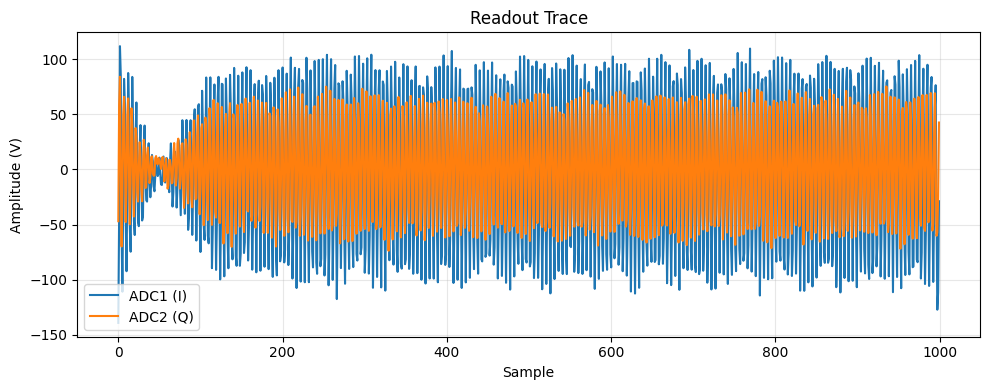

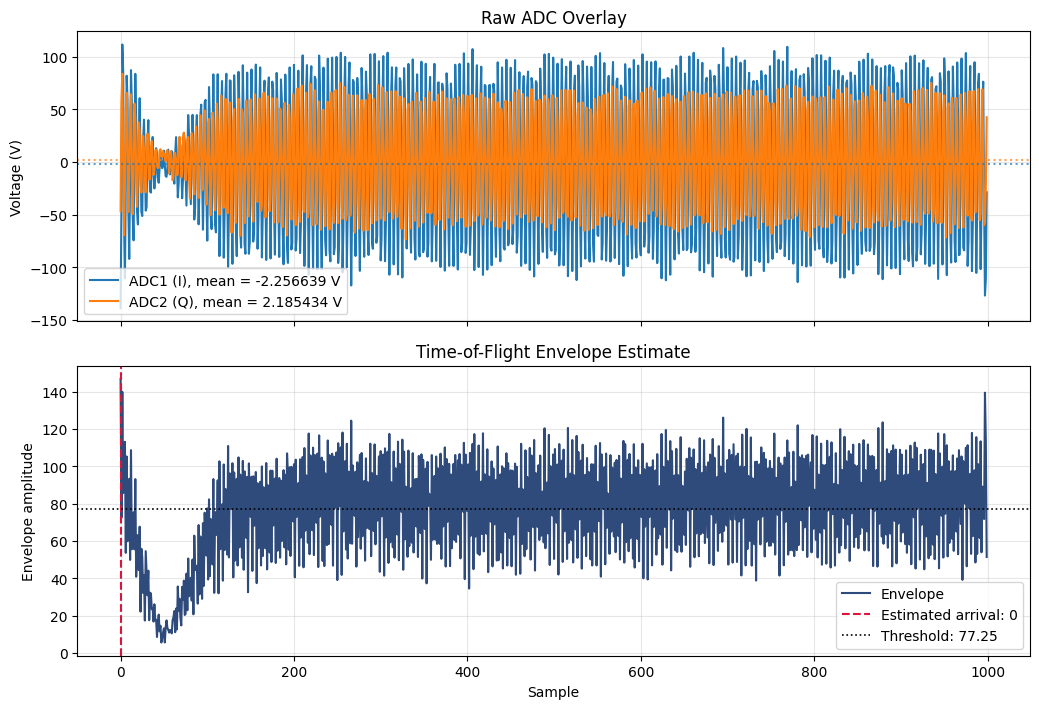

Trace length: 1000 samples
ADC1 mean: -2.256639 V
ADC2 mean: 2.185434 V
Estimated arrival sample: 0


In [4]:
def estimate_time_of_flight_sample(adc1: np.ndarray, adc2: np.ndarray, threshold_fraction: float = 0.2) -> tuple[int, np.ndarray, float]:
    envelope = np.sqrt(np.square(adc1) + np.square(adc2))
    head = envelope[: min(32, envelope.size)]
    baseline = float(np.median(head)) if head.size else 0.0
    peak = float(np.max(envelope)) if envelope.size else baseline
    threshold = baseline + threshold_fraction * (peak - baseline)
    above = np.flatnonzero(envelope >= threshold)
    sample_index = int(above[0]) if above.size else int(np.argmax(envelope))
    return sample_index, envelope, threshold


def reopen_time_of_flight_session() -> None:
    global session, attr
    close_shared_session()
    session = require_shared_session(
        registry_base=REGISTRY_BASE,
        sample_id=SAMPLE_ID,
        cooldown_id=COOLDOWN_ID,
        qop_ip=QOP_IP,
        cluster_name=CLUSTER_NAME,
        force_reopen=True,
    )
    context_snapshot = getattr(session, "context_snapshot", None)
    attr = context_snapshot() if callable(context_snapshot) else getattr(session, "attributes", None)
    if attr is None:
        raise RuntimeError("Unable to resolve the cQED attribute snapshot after reopening the shared session.")


last_error = None
tof_result = None
for attempt in range(2):
    try:
        trace = ReadoutTrace(session)
        tof_result = trace.run(
            drive_frequency=TIME_OF_FLIGHT_DRIVE_FREQUENCY,
            ro_therm_clks=TIME_OF_FLIGHT_RO_THERM_CLKS,
            n_avg=TIME_OF_FLIGHT_N_AVG,
        )
        break
    except Exception as exc:
        last_error = exc
        message = str(exc).lower()
        retryable = "connection lost" in message or "machine not found" in message
        if attempt == 0 and retryable:
            print("ReadoutTrace lost the QM connection; reopening the shared session and retrying once.")
            reopen_time_of_flight_session()
            continue
        raise

if tof_result is None:
    raise RuntimeError(f"ReadoutTrace did not return a result. Last error: {last_error}")

tof_analysis = trace.analyze(tof_result)
trace.plot(tof_analysis)

adc1 = tof_analysis.data.get("adc1")
adc2 = tof_analysis.data.get("adc2")
if adc1 is None or adc2 is None:
    raise RuntimeError("ReadoutTrace output did not contain adc1/adc2 arrays.")

adc1 = np.asarray(adc1, dtype=float)
adc2 = np.asarray(adc2, dtype=float)
sample_axis = np.arange(adc1.size, dtype=float)
adc1_mean = float(np.mean(adc1))
adc2_mean = float(np.mean(adc2))
tof_sample, tof_envelope, tof_threshold = estimate_time_of_flight_sample(
    adc1,
    adc2,
    threshold_fraction=TIME_OF_FLIGHT_THRESHOLD_FRACTION,
)

fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.2), sharex=True)

axes[0].plot(sample_axis, adc1, label=f"ADC1 (I), mean = {adc1_mean:.6f} V")
axes[0].plot(sample_axis, adc2, label=f"ADC2 (Q), mean = {adc2_mean:.6f} V")
axes[0].axhline(adc1_mean, color="#1f77b4", ls=":", alpha=0.7)
axes[0].axhline(adc2_mean, color="#ff7f0e", ls=":", alpha=0.7)
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title("Raw ADC Overlay")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(sample_axis, tof_envelope, label="Envelope", color="#2f4b7c")
axes[1].axvline(tof_sample, color="crimson", ls="--", lw=1.5, label=f"Estimated arrival: {tof_sample}")
axes[1].axhline(tof_threshold, color="black", ls=":", lw=1.2, label=f"Threshold: {tof_threshold:.4g}")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Envelope amplitude")
axes[1].set_title("Time-of-Flight Envelope Estimate")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Trace length: {tof_analysis.metrics.get('trace_length', 'N/A')} samples")
print(f"ADC1 mean: {adc1_mean:.6f} V")
print(f"ADC2 mean: {adc2_mean:.6f} V")
print(f"Estimated arrival sample: {tof_sample}")

In [5]:
# --- TOF at multiple IF offsets ---
# Run ReadoutTrace at +5 MHz and -5 MHz IF offsets relative to the nominal
# readout frequency to confirm the arrival time is frequency-independent.
offsets_mhz = [+5.0, -5.0]
results_by_offset = {}

for offset_mhz in offsets_mhz:
    freq = TIME_OF_FLIGHT_DRIVE_FREQUENCY + offset_mhz * 1e6
    print(f"\n--- IF offset: {offset_mhz:+.1f} MHz → drive = {freq/1e9:.6f} GHz ---")
    trace_off = ReadoutTrace(session)
    res = trace_off.run(
        drive_frequency=freq,
        ro_therm_clks=TIME_OF_FLIGHT_RO_THERM_CLKS,
        n_avg=TIME_OF_FLIGHT_N_AVG,
    )
    analysis = trace_off.analyze(res)
    a1 = np.asarray(analysis.data.get("adc1"), dtype=float)
    a2 = np.asarray(analysis.data.get("adc2"), dtype=float)
    s_idx, env, thr = estimate_time_of_flight_sample(a1, a2, TIME_OF_FLIGHT_THRESHOLD_FRACTION)
    results_by_offset[offset_mhz] = {
        "arrival_sample": s_idx,
        "adc1_mean": float(np.mean(a1)),
        "adc2_mean": float(np.mean(a2)),
        "envelope_peak": float(np.max(env)),
    }
    print(f"  Arrival sample: {s_idx}")
    print(f"  ADC1 mean: {float(np.mean(a1)):.4f} V")
    print(f"  ADC2 mean: {float(np.mean(a2)):.4f} V")
    print(f"  Envelope peak: {float(np.max(env)):.2f}")

print("\n--- Summary ---")
print(f"  Nominal    (0 MHz offset): arrival = {tof_sample}, envelope peak = {float(np.max(tof_envelope)):.2f}")
for off, info in results_by_offset.items():
    print(f"  {off:+.1f} MHz offset: arrival = {info['arrival_sample']}, envelope peak = {info['envelope_peak']:.2f}")
print(f"\n  Hardware time_of_flight setting: 280 samples")
print(f"  TOF appears {'consistent' if all(v['arrival_sample'] < 10 for v in results_by_offset.values()) and tof_sample < 10 else 'inconsistent'} across IF offsets.")


--- IF offset: +5.0 MHz → drive = 8.601223 GHz ---
2026-03-24 01:49:18,359 - qm - INFO     - Sending program to QOP for compilation
2026-03-24 01:49:18,405 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 999/1000 [00:00<00:00, 2561.84it/s]


  Arrival sample: 0
  ADC1 mean: -2.2556 V
  ADC2 mean: 2.1223 V
  Envelope peak: 164.44

--- IF offset: -5.0 MHz → drive = 8.591223 GHz ---
2026-03-24 01:49:18,926 - qm - INFO     - Sending program to QOP for compilation
2026-03-24 01:49:19,013 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 999/1000 [00:00<00:00, 2581.65it/s]


  Arrival sample: 0
  ADC1 mean: -2.0973 V
  ADC2 mean: 2.1197 V
  Envelope peak: 197.87

--- Summary ---
  Nominal    (0 MHz offset): arrival = 0, envelope peak = 146.78
  +5.0 MHz offset: arrival = 0, envelope peak = 164.44
  -5.0 MHz offset: arrival = 0, envelope peak = 197.87

  Hardware time_of_flight setting: 280 samples
  TOF appears consistent across IF offsets.
